# EDA - Dataset clínico de 210 pacientes

**Proyecto:** TFM - Técnicas avanzadas de IA para predicción y caracterización de complicaciones en biopsias pulmonares.

**Objetivo del notebook**

Este notebook realiza un análisis exploratorio completo del dataset clínico de 210 pacientes.
El análisis principal parte de un CSV ya categorizado. Además, se usa el CSV original para describir las categorías clínicas antes de su codificación.

**Objetivos concretos del EDA**

- validar integridad básica del dataset
- estudiar las etiquetas de complicación
- analizar la distribución de variables clínicas y patológicas
- identificar desbalanceos y rareza de etiquetas
- generar visualizaciones

In [94]:
# Importaciones y librerias
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
matplotlib.rcParams['figure.figsize'] = (8, 5)
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

In [95]:
# Ruta y carga de datos
DATA_PATH = Path('/home/mcribilles/tfm/clinical_data/210pacientes/clinical_data_limpios.csv')
RAW_DATA_PATH = DATA_PATH.with_name('clinical_data.csv')
print(DATA_PATH, '->', DATA_PATH.exists())
print(RAW_DATA_PATH, '->', RAW_DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)
df_raw = pd.read_csv(RAW_DATA_PATH)
print('Shape limpio:', df.shape)
print('Shape original:', df_raw.shape)

/home/mcribilles/tfm/clinical_data/210pacientes/clinical_data_limpios.csv -> True
/home/mcribilles/tfm/clinical_data/210pacientes/clinical_data.csv -> True
Shape limpio: (210, 52)
Shape original: (210, 8)


En el limpio tenemos 52 variables porque las tenemos ya categorizadas, por eso en el original hay menos columnas.

## 1. Vista general del dataset

Comenzamos comprobando dimensiones, tipos de variables, nulos e identificadores únicos para verificar que el dataset está correctamente cargado y preparado para el análisis.

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   patient_id                       210 non-null    str  
 1   Edad                             210 non-null    int64
 2   Derrame_pleural                  210 non-null    int64
 3   Hemorragia                       210 non-null    int64
 4   Neumotórax                       210 non-null    int64
 5   Sin_complicación                 210 non-null    int64
 6   AOS                              210 non-null    int64
 7   Alcoholismo                      210 non-null    int64
 8   Aneurisma_esplénico              210 non-null    int64
 9   Asma                             210 non-null    int64
 10  Cardiopatía                      210 non-null    int64
 11  Craniofaringioma                 210 non-null    int64
 12  Cáncer_de_mama                   210 non-null    int64
 13  D

In [97]:
print('Número de pacientes:', len(df))
print('Número de columnas:', df.shape[1])
print('Nulos totales:', int(df.isna().sum().sum()))
print('IDs únicos:', df['patient_id'].nunique())
print('Duplicados de ID:', int(df['patient_id'].duplicated().sum()))

display(df.head())

Número de pacientes: 210
Número de columnas: 52
Nulos totales: 0
IDs únicos: 210
Duplicados de ID: 0


,patient_id,Edad,Derrame_pleural,Hemorragia,Neumotórax,Sin_complicación,AOS,Alcoholismo,Aneurisma_esplénico,Asma,Cardiopatía,Craniofaringioma,Cáncer_de_mama,DM,DM1,DM2,Dislipemia,EPOC,Encefalopatía,Enfermedad_de_von_Willebrand,Epilepsia,Exalcoholismo,Extabaquismo,FRVC,HBP,HTA,Hipercolesterolemia,Hiperlipemia,Hiperuricemia,Macroglobulinemia_de_Waldestrom,NAMC,Obesidad,SCACEST,Sin_factor_de_riesgo,Tabaquismo,Tabaquismo_pasivo,VIH,Asbestosis,Atelectasia_crónica,Bronquiectasias,Enfisema,Enfisema_centrolobulillar,Enfisema_panacinar,Enfisema_paraseptal,Fibrosis,Fibrosis_pulmonar,Hipertensión_pulmonar,Neumoconiosis,Neumonía,Sin_patología_pulmonar,Sexo_binaria,Complicacion_binaria
0,1MASh,77,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,2HENX,61,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
2,3HENX,84,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,4HLSh,31,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,5HANX,62,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


In [98]:
print('Valores nulos por columna:')
display(df.isnull().sum().sort_values(ascending=False))

Valores nulos por columna:


patient_id                         0
Edad                               0
Derrame_pleural                    0
Hemorragia                         0
Neumotórax                         0
Sin_complicación                   0
AOS                                0
Alcoholismo                        0
Aneurisma_esplénico                0
Asma                               0
Cardiopatía                        0
Craniofaringioma                   0
Cáncer_de_mama                     0
DM                                 0
DM1                                0
DM2                                0
Dislipemia                         0
EPOC                               0
Encefalopatía                      0
Enfermedad_de_von_Willebrand       0
Epilepsia                          0
Exalcoholismo                      0
Extabaquismo                       0
FRVC                               0
HBP                                0
HTA                                0
Hipercolesterolemia                0
H

In [99]:
# Estadisticas descriptivas, aunque la mayoria de columnas son binarias
display(df.describe(include='all'))

,patient_id,Edad,Derrame_pleural,Hemorragia,Neumotórax,Sin_complicación,AOS,Alcoholismo,Aneurisma_esplénico,Asma,Cardiopatía,Craniofaringioma,Cáncer_de_mama,DM,DM1,DM2,Dislipemia,EPOC,Encefalopatía,Enfermedad_de_von_Willebrand,Epilepsia,Exalcoholismo,Extabaquismo,FRVC,HBP,HTA,Hipercolesterolemia,Hiperlipemia,Hiperuricemia,Macroglobulinemia_de_Waldestrom,NAMC,Obesidad,SCACEST,Sin_factor_de_riesgo,Tabaquismo,Tabaquismo_pasivo,VIH,Asbestosis,Atelectasia_crónica,Bronquiectasias,Enfisema,Enfisema_centrolobulillar,Enfisema_panacinar,Enfisema_paraseptal,Fibrosis,Fibrosis_pulmonar,Hipertensión_pulmonar,Neumoconiosis,Neumonía,Sin_patología_pulmonar,Sexo_binaria,Complicacion_binaria
count,210,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
unique,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1MASh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,65.966667,0.004762,0.233333,0.304762,0.500000,0.033333,0.014286,0.004762,0.004762,0.014286,0.004762,0.004762,0.047619,0.004762,0.014286,0.066667,0.019048,0.004762,0.004762,0.004762,0.004762,0.300000,0.004762,0.004762,0.309524,0.014286,0.004762,0.004762,0.004762,0.004762,0.038095,0.004762,0.161905,0.433333,0.004762,0.004762,0.004762,0.004762,0.014286,0.009524,0.195238,0.004762,0.109524,0.033333,0.004762,0.080952,0.004762,0.004762,0.633333,0.642857,0.500000
std,NaN,12.974168,0.069007,0.423963,0.461406,0.501195,0.179934,0.118950,0.069007,0.069007,0.118950,0.069007,0.069007,0.213468,0.069007,0.118950,0.250040,0.137019,0.069007,0.069007,0.069007,0.069007,0.459353,0.069007,0.069007,0.463402,0.118950,0.069007,0.069007,0.069007,0.069007,0.191884,0.069007,0.369244,0.496720,0.069007,0.069007,0.069007,0.069007,0.118950,0.097356,0.397331,0.069007,0.313042,0.179934,0.069007,0.273414,0.069007,0.069007,0.483046,0.480302,0.501195
min,NaN,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,68.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

## 2. Perfil oncológico de la cohorte

El tipo de cáncer no se conserva en el CSV limpio, por lo que este gráfico se calcula a partir de `clinical_data.csv`.

Los valores `X`, vacíos y nulos se muestran como `No especificado`.

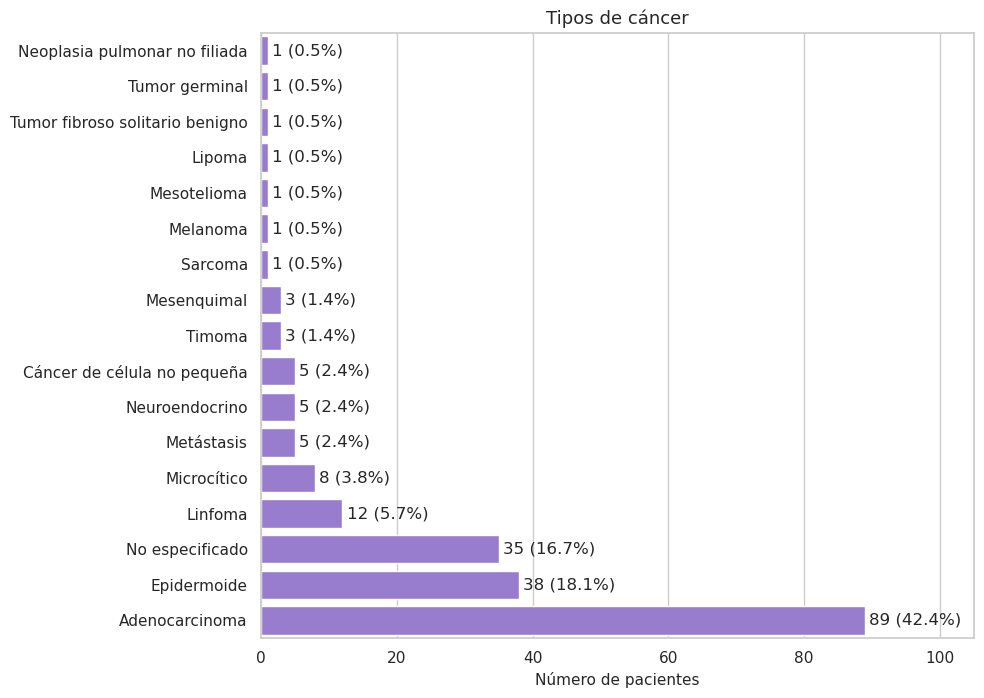

In [100]:
# preparacion y grafico de categorias del CSV original
MARCADORES_AUSENCIA = {'', 'x', 'nan', 'none'}

def tabla_frecuencias_original(serie, multietiqueta=False, incluir_no_especificado=False):
    valores = serie.fillna('').astype(str).str.strip()
    if multietiqueta:
        valores = valores.str.split(',').explode().str.strip()

    es_ausencia = valores.str.lower().isin(MARCADORES_AUSENCIA)
    if incluir_no_especificado:
        valores = valores.mask(es_ausencia, 'No especificado')
    else:
        valores = valores.loc[~es_ausencia]

    tabla = valores.value_counts().rename_axis('categoría').reset_index(name='n_pacientes')
    tabla['porcentaje'] = (100 * tabla['n_pacientes'] / len(df_raw)).round(1)
    return tabla

# agrupacion clinica de denominaciones equivalentes antes de cualquier grafico
def normalizar_tipo_cancer(serie):
    tipos = (
        serie.fillna('No especificado')
        .astype(str)
        .str.strip()
        .replace({'': 'No especificado', 'X': 'No especificado', 'x': 'No especificado'})
    )
    return tipos.replace({
        'Carcinoma epidermoide': 'Epidermoide',
        'Carcinoma de célula no pequeña': 'Cáncer de célula no pequeña',
        'Metástasis cáncer de endometrio': 'Metástasis',
        'Metástasis mama': 'Metástasis',
        'Tumor indiferenciado': 'No especificado',
    })

tipo_cancer_normalizado = normalizar_tipo_cancer(df_raw['Tipo de cáncer'])
cancer_original = tabla_frecuencias_original(
    tipo_cancer_normalizado, incluir_no_especificado=True
)
patologias_original = tabla_frecuencias_original(
    df_raw['Patología pulmonar'], multietiqueta=True
)
riesgos_original = tabla_frecuencias_original(
    df_raw['Factor de riesgo'], multietiqueta=True
)

def grafico_frecuencias(tabla, titulo, color):
    datos = tabla.sort_values('n_pacientes')
    alto = max(4, 0.42 * len(datos))
    fig, ax = plt.subplots(figsize=(10, alto))
    sns.barplot(data=datos, y='categoría', x='n_pacientes', color=color, ax=ax)
    ax.bar_label(
        ax.containers[0],
        labels=[f"{n} ({p:.1f}%)" for n, p in zip(datos['n_pacientes'], datos['porcentaje'])],
        padding=3,
    )
    ax.set_title(titulo)
    ax.set_xlabel('Número de pacientes')
    ax.set_ylabel('')
    ax.set_xlim(0, datos['n_pacientes'].max() * 1.18)
    plt.tight_layout()
    plt.show()

grafico_frecuencias(
    cancer_original, 'Tipos de cáncer', 'mediumpurple'
)

### Complicación según tipo de cáncer

Se utiliza el tipo de cáncer del CSV original y se comprueba que el orden de pacientes coincida con el CSV limpio. Las categorías con muy pocos pacientes se mantienen en la tabla de soporte, pero no se representan en el gráfico para evitar interpretar porcentajes basados en uno o dos casos.

,Tipo_cancer_original,n_pacientes,n_complicacion,n_sin_complicacion,tasa_complicacion_pct
0,Adenocarcinoma,89,55,34,61.8
2,Epidermoide,38,16,22,42.1
12,No especificado,35,17,18,48.6
3,Linfoma,12,2,10,16.7
9,Microcítico,8,4,4,50.0
1,Cáncer de célula no pequeña,5,3,2,60.0
11,Neuroendocrino,5,1,4,20.0
8,Metástasis,5,3,2,60.0
6,Mesenquimal,3,1,2,33.3
14,Timoma,3,0,3,0.0


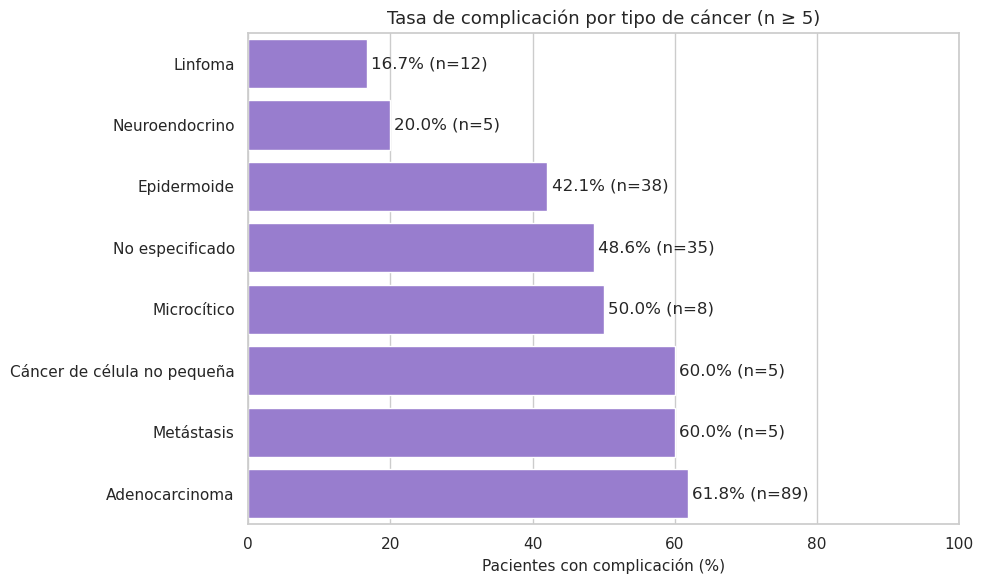

In [101]:
# comprobacion: se une por posicion solo si ambos CSV tienen el mismo orden de pacientes
if not df['patient_id'].astype(str).equals(df_raw['patient_id'].astype(str)):
    raise ValueError('Los IDs del CSV limpio y original no están alineados.')

df_cancer = df[['patient_id', 'Complicacion_binaria']].copy()
# Se reutiliza la misma agrupacion aplicada al grafico del perfil oncologico
df_cancer['Tipo_cancer_original'] = tipo_cancer_normalizado

resumen_cancer = (
    df_cancer.groupby('Tipo_cancer_original', as_index=False)
    .agg(
        n_pacientes=('patient_id', 'size'),
        n_complicacion=('Complicacion_binaria', 'sum'),
    )
)
resumen_cancer['n_sin_complicacion'] = (
    resumen_cancer['n_pacientes'] - resumen_cancer['n_complicacion']
)
resumen_cancer['tasa_complicacion_pct'] = (
    100 * resumen_cancer['n_complicacion'] / resumen_cancer['n_pacientes']
).round(1)
resumen_cancer = resumen_cancer.sort_values('n_pacientes', ascending=False)
display(resumen_cancer)

MIN_N_CANCER = 5
cancer_plot = resumen_cancer.query('n_pacientes >= @MIN_N_CANCER').sort_values('tasa_complicacion_pct')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=cancer_plot, x='tasa_complicacion_pct', y='Tipo_cancer_original',
    color='mediumpurple', ax=ax
)
ax.bar_label(
    ax.containers[0],
    labels=[f"{tasa:.1f}% (n={n})" for tasa, n in zip(
        cancer_plot['tasa_complicacion_pct'], cancer_plot['n_pacientes']
    )],
    padding=3,
)
ax.set(
    title=f'Tasa de complicación por tipo de cáncer (n ≥ {MIN_N_CANCER})',
    xlabel='Pacientes con complicación (%)', ylabel=''
)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

Adenocarcinoma es el grupo dominante (89 pacientes; 61,8 % con complicación), seguido de epidermoide (38; 42,1 %), el grupo sin tipo especificado (35; 48,6 %), linfoma (12; 16,7 %) y microcítico (8; 50,0 %). Las categorías de cáncer de célula no pequeña, metástasis y neuroendocrino tienen el mínimo de representación empleado para el gráfico (5 pacientes cada una), por lo que sus tasas deben leerse con cautela. Las diferencias aparentes no deben considerarse asociaciones estadísticamente confirmadas: salvo adenocarcinoma, epidermoide y el grupo no especificado, el soporte es reducido. Las categorías con menos de cinco pacientes se excluyen del gráfico, pero permanecen documentadas en la tabla.

## 3. Estructura de variables

El dataset contiene:

- identificador de paciente
- edad
- etiquetas objetivo de complicación
- variables binarias de factores de riesgo
- variables binarias de patología pulmonar
- sexo codificado
- complicación binaria global.

In [102]:
print('Columnas del dataset:')
for i, col in enumerate(df.columns):
    print(f'{i:02d}. {col}')

Columnas del dataset:
00. patient_id
01. Edad
02. Derrame_pleural
03. Hemorragia
04. Neumotórax
05. Sin_complicación
06. AOS
07. Alcoholismo
08. Aneurisma_esplénico
09. Asma
10. Cardiopatía
11. Craniofaringioma
12. Cáncer_de_mama
13. DM
14. DM1
15. DM2
16. Dislipemia
17. EPOC
18. Encefalopatía
19. Enfermedad_de_von_Willebrand
20. Epilepsia
21. Exalcoholismo
22. Extabaquismo
23. FRVC
24. HBP
25. HTA
26. Hipercolesterolemia
27. Hiperlipemia
28. Hiperuricemia
29. Macroglobulinemia_de_Waldestrom
30. NAMC
31. Obesidad
32. SCACEST
33. Sin_factor_de_riesgo
34. Tabaquismo
35. Tabaquismo_pasivo
36. VIH
37. Asbestosis
38. Atelectasia_crónica
39. Bronquiectasias
40. Enfisema
41. Enfisema_centrolobulillar
42. Enfisema_panacinar
43. Enfisema_paraseptal
44. Fibrosis
45. Fibrosis_pulmonar
46. Hipertensión_pulmonar
47. Neumoconiosis
48. Neumonía
49. Sin_patología_pulmonar
50. Sexo_binaria
51. Complicacion_binaria


In [103]:
# separacion de bloques de variables
label_cols = ['Derrame_pleural', 'Hemorragia', 'Neumotórax', 'Sin_complicación', 'Complicacion_binaria']
base_cols = ['patient_id', 'Edad', 'Sexo_binaria']
aux_exclude = set(base_cols + label_cols)
feature_cols = [c for c in df.columns if c not in aux_exclude]

print('Variables base:', base_cols)
print('Variables objetivo:', label_cols)
print('Número de variables clínicas/patológicas binarias:', len(feature_cols))

Variables base: ['patient_id', 'Edad', 'Sexo_binaria']
Variables objetivo: ['Derrame_pleural', 'Hemorragia', 'Neumotórax', 'Sin_complicación', 'Complicacion_binaria']
Número de variables clínicas/patológicas binarias: 44


Dependiendo de la clasificación que queramos hacer se utilizará una variable objetivo u otras.

## 4. Análisis de etiquetas objetivo

Aquí analizamos el soporte de las complicaciones y comprobamos si la formulación del problema es compatible con una visión multietiqueta.

Antes de empezar, vamos a hacer una breve comprobación de la coherencia entre etiquetas:  

In [104]:
multi_target_cols = ['Derrame_pleural', 'Hemorragia', 'Neumotórax']

checks = {
    'Complicacion_binaria coincide con alguna complicación específica':
        (df['Complicacion_binaria'] == (df[multi_target_cols].sum(axis=1) > 0).astype(int)).all(),

    'Sin_complicación coincide con ausencia de complicaciones específicas':
        (df['Sin_complicación'] == (df[multi_target_cols].sum(axis=1) == 0).astype(int)).all(),

    'Complicacion_binaria y Sin_complicación son complementarias':
        (df['Complicacion_binaria'] == 1 - df['Sin_complicación']).all()
}

display(pd.Series(checks, name='resultado'))

Complicacion_binaria coincide con alguna complicación específica        True
Sin_complicación coincide con ausencia de complicaciones específicas    True
Complicacion_binaria y Sin_complicación son complementarias             True
Name: resultado, dtype: bool

In [105]:
label_summary = pd.DataFrame({
    'etiqueta': label_cols,
    'n_positivos': [int(df[c].sum()) for c in label_cols],
    'proporcion': [df[c].mean() for c in label_cols]
})

sin_complicacion_especifica = df[multi_target_cols].sum(axis=1) == 0

label_summary_multietiqueta = pd.concat([
    label_summary[label_summary['etiqueta'].isin(multi_target_cols)].copy(),
    pd.DataFrame({
        'etiqueta': ['Sin complicación específica'],
        'n_positivos': [int(sin_complicacion_especifica.sum())],
        'proporcion': [sin_complicacion_especifica.mean()]
    })
], ignore_index=True)
label_summary_binaria = label_summary[label_summary['etiqueta'].isin(['Sin_complicación', 'Complicacion_binaria'])].copy()

display(label_summary)

,etiqueta,n_positivos,proporcion
0,Derrame_pleural,1,0.004762
1,Hemorragia,49,0.233333
2,Neumotórax,64,0.304762
3,Sin_complicación,105,0.500000
4,Complicacion_binaria,105,0.500000


Sin complicación y Complicación binaria son complementarias. Para evitar mezclar niveles de información, el soporte se visualiza en dos gráficos: uno para las complicaciones específicas multietiqueta, incluyendo el grupo sin ninguna complicación específica, y otro para la etiqueta resumen binaria. En el primer gráfico, las barras de complicaciones pueden solaparse si un paciente tiene más de una complicación etiquetada.

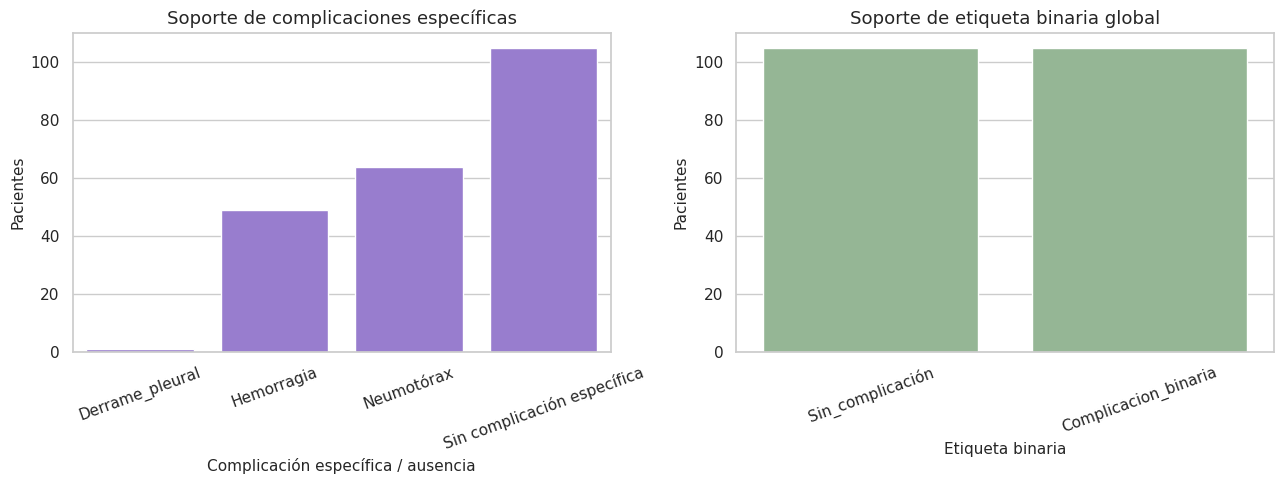

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=label_summary_multietiqueta,
    x='etiqueta',
    y='n_positivos',
    color='mediumpurple',
    ax=axes[0]
)
axes[0].set_title('Soporte de complicaciones específicas')
axes[0].set_xlabel('Complicación específica / ausencia')
axes[0].set_ylabel('Pacientes')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=label_summary_binaria,
    x='etiqueta',
    y='n_positivos',
    color='darkseagreen',
    ax=axes[1]
)
axes[1].set_title('Soporte de etiqueta binaria global')
axes[1].set_xlabel('Etiqueta binaria')
axes[1].set_ylabel('Pacientes')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Vemos como si hacemos una clasificación binaria, la etiqueta objetivo está balanceada. Sin embargo, si cogemos multietiqueta (se puede dar varias complicaciones a la vez), la complicación de derrame pleural solo tiene un paciente, por lo que sería despreciable. Además, la clase mayoritaria es la de sin complicación, por lo que hay desbalanceo para este tipo de clasificación.

n_complicaciones_etiquetadas
0    105
1     96
2      9
Name: count, dtype: int64


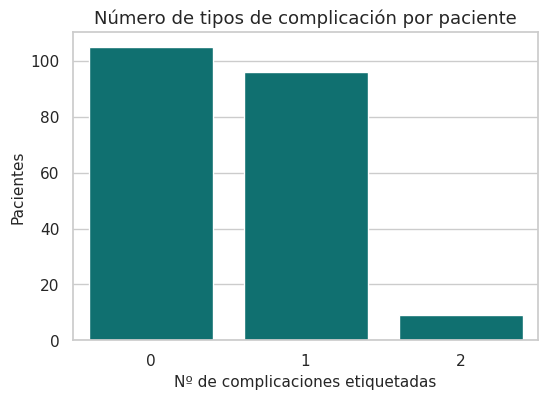

In [107]:
# Numero de tipos de complicacion por paciente
multi_target_cols = ['Derrame_pleural', 'Hemorragia', 'Neumotórax']
df['n_complicaciones_etiquetadas'] = df[multi_target_cols].sum(axis=1)

comp_per_patient = df['n_complicaciones_etiquetadas'].value_counts().sort_index()
print(comp_per_patient)

plt.figure(figsize=(6,4))
sns.barplot(x=comp_per_patient.index.astype(str), y=comp_per_patient.values, color='teal')
plt.title('Número de tipos de complicación por paciente')
plt.xlabel('Nº de complicaciones etiquetadas')
plt.ylabel('Pacientes')
plt.show()

Realmente hay muy pocos pacientes que tienen varias complicaciones a la vez.

,Derrame_pleural,Hemorragia,Neumotórax
Derrame_pleural,1,0,0
Hemorragia,0,49,9
Neumotórax,0,9,64


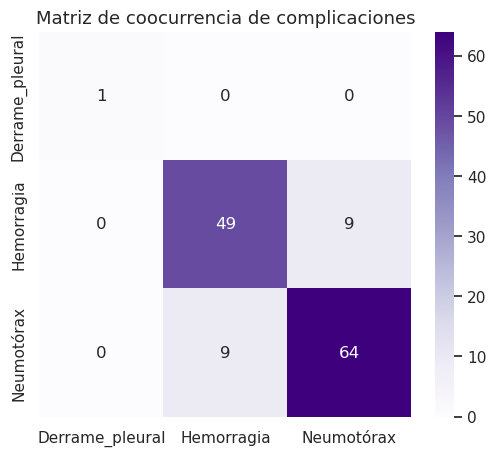

In [108]:
# Coocurrencia entre complicaciones
cooc = df[multi_target_cols].T.dot(df[multi_target_cols])
display(cooc)

plt.figure(figsize=(6,5))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de coocurrencia de complicaciones')
plt.show()

Entre las complicaciones, la más usual es el neumotórax.

In [109]:
# Combinaciones exactas de etiquetas de complicacion
combo_counts = (
    df[multi_target_cols]
    .astype(int)
    .astype(str)
    .agg('-'.join, axis=1)
    .value_counts()
    .rename_axis('combinacion')
    .reset_index(name='n_pacientes')
)

display(combo_counts)

,combinacion,n_pacientes
0,0-0-0,105
1,0-0-1,55
2,0-1-0,40
3,0-1-1,9
4,1-0-0,1


Solo tenemos 9 pacientes con dos complicaciones a la vez. Derrame pleural solo hay un paciente. 

## 5. Variables demográficas básicas

/tmp/ipykernel_512152/2202607644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Complicacion_binaria', y='Edad', ax=axes[1], palette='pastel')


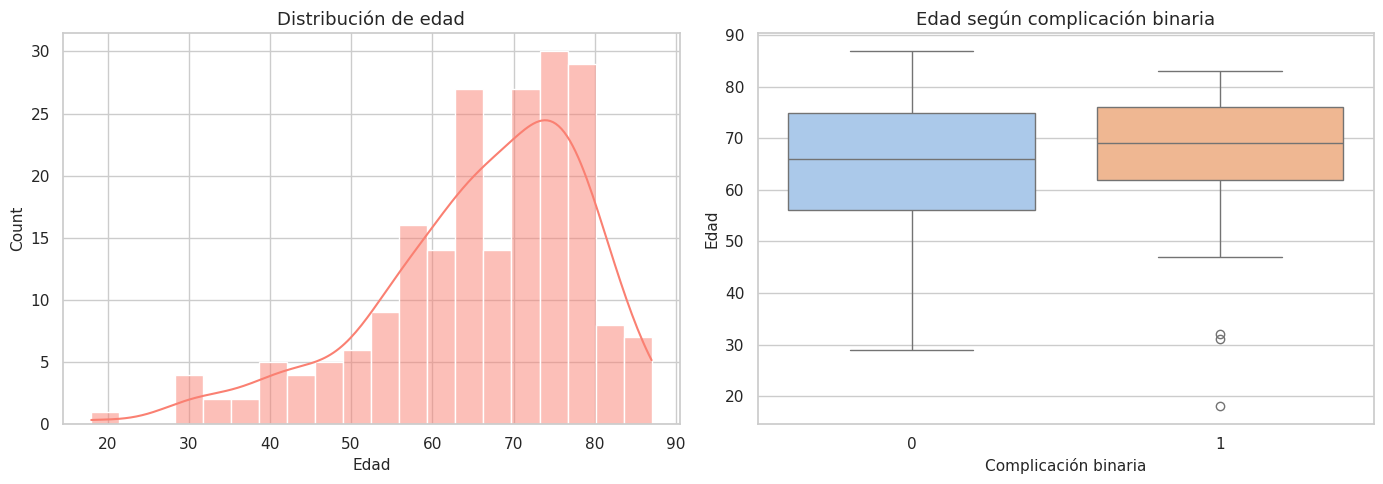

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df, x='Edad', bins=20, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribución de edad')

sns.boxplot(data=df, x='Complicacion_binaria', y='Edad', ax=axes[1], palette='pastel')
axes[1].set_title('Edad según complicación binaria')
axes[1].set_xlabel('Complicación binaria')

plt.tight_layout()
plt.show()

### Análisis univariante de la edad

La edad es la única variable cuantitativa de la cohorte. Se describe con medidas de tendencia central y dispersión, forma de la distribución y una comprobación orientativa de normalidad. Dado que la normalidad exacta no es necesaria para el EDA, el resultado de Shapiro-Wilk se interpreta junto con los gráficos y los estadísticos robustos (mediana e IQR).

,valor
n,210.000
media,65.967
desviación estándar,12.974
mínimo,18.000
Q1,59.000
mediana,68.000
Q3,76.000
IQR,17.000
máximo,87.000
asimetría,-0.993


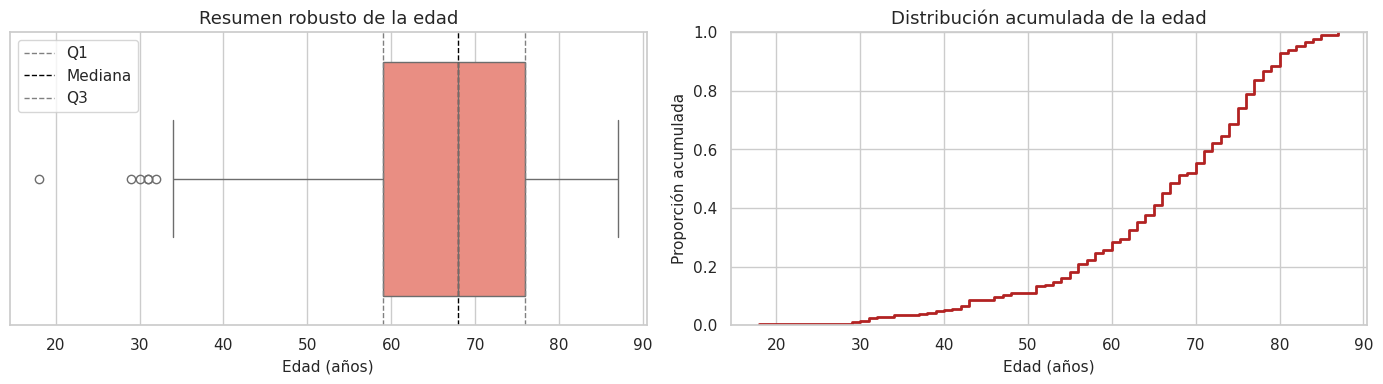

In [111]:
from scipy.stats import kurtosis, shapiro, skew

edad = df['Edad'].dropna()
q1, q3 = edad.quantile([0.25, 0.75])
iqr_edad = q3 - q1
shapiro_stat, shapiro_p = shapiro(edad)

edad_stats = pd.DataFrame({
    'valor': [
        edad.size, edad.mean(), edad.std(), edad.min(), q1, edad.median(), q3,
        iqr_edad, edad.max(), skew(edad), kurtosis(edad, fisher=False),
        shapiro_stat, shapiro_p,
    ]
}, index=[
    'n', 'media', 'desviación estándar', 'mínimo', 'Q1', 'mediana', 'Q3',
    'IQR', 'máximo', 'asimetría', 'curtosis de Pearson', 'Shapiro-Wilk W',
    'Shapiro-Wilk p-valor',
]).round(3)
display(edad_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=edad, color='salmon', ax=axes[0])
for valor, etiqueta, color in [(q1, 'Q1', 'gray'), (edad.median(), 'Mediana', 'black'), (q3, 'Q3', 'gray')]:
    axes[0].axvline(valor, color=color, linestyle='--', linewidth=1, label=etiqueta)
axes[0].set_title('Resumen robusto de la edad')
axes[0].set_xlabel('Edad (años)')
axes[0].legend()

sns.ecdfplot(x=edad, color='firebrick', linewidth=2, ax=axes[1])
axes[1].set_title('Distribución acumulada de la edad')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Proporción acumulada')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

La cohorte tiene una edad central de 68 años (IQR: 59-76) y un rango de 18 a 87 años. La media (66,0 años) es algo menor que la mediana y la asimetría es negativa, coherente con una cola hacia edades jóvenes. El test de Shapiro-Wilk rechaza normalidad exacta (p < 0,001), por lo que para describir edad conviene informar tanto media/desviación estándar como mediana/IQR.

### Valores extremos según el criterio IQR

Estos valores son observaciones alejadas de la distribución central, no errores automáticamente. Se revisan para confirmar su plausibilidad clínica y de registro, pero no se eliminan por este criterio. Además, en un dataset médico tan pequeño como el nuestro, es imprescindible tener cuantas más muestras mejor, por lo que el estudio de los valores extremos solo es informativo, no eliminativo.

In [112]:
lower = q1 - 1.5 * iqr_edad
upper = q3 + 1.5 * iqr_edad

edad_outliers = df[(df['Edad'] < lower) | (df['Edad'] > upper)]
print(f'Intervalo IQR esperado: [{lower:.1f}, {upper:.1f}] años')
print(f'Observaciones fuera del intervalo: {len(edad_outliers)} ({100 * len(edad_outliers) / len(df):.1f} %)')
display(edad_outliers[['patient_id', 'Edad', 'Complicacion_binaria']])

Intervalo IQR esperado: [33.5, 101.5] años
Observaciones fuera del intervalo: 6 (2.9 %)


,patient_id,Edad,Complicacion_binaria
3,4HLSh,31,1
13,14MLNX,30,0
47,48HTtSN,18,1
76,77MXSH,32,1
129,130HTgNX,31,0
161,162MLNX,29,0


Todos los outliers son por edades jóvenes. El más extremo es un paciente con 18 años. Lo más normal es que las personas con cáncer de pulmón sean más mayores.

### Distribución por grupos de edad

La agrupación es unicamente informativa porque para el modelado, la edad se conserva como variable continua.

,grupo_edad,n_pacientes,porcentaje
0,<40,10,4.8
1,40–49,13,6.2
2,50–59,31,14.8
3,60–69,55,26.2
4,70–79,77,36.7
5,≥80,24,11.4


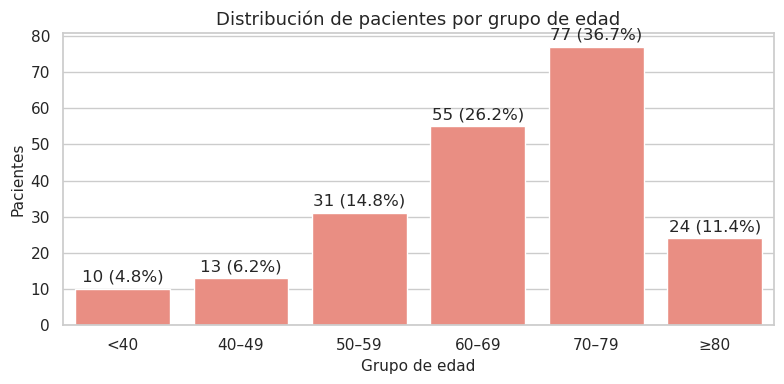

In [113]:
grupos_edad = pd.cut(
    edad,
    bins=[0, 40, 50, 60, 70, 80, np.inf],
    labels=['<40', '40–49', '50–59', '60–69', '70–79', '≥80'],
    right=False,
)
resumen_grupos_edad = (
    grupos_edad.value_counts(sort=False)
    .rename_axis('grupo_edad')
    .reset_index(name='n_pacientes')
)
resumen_grupos_edad['porcentaje'] = (
    100 * resumen_grupos_edad['n_pacientes'] / len(edad)
).round(1)
display(resumen_grupos_edad)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=resumen_grupos_edad, x='grupo_edad', y='n_pacientes', color='salmon', ax=ax)
ax.bar_label(
    ax.containers[0],
    labels=[f"{n} ({p:.1f}%)" for n, p in zip(
        resumen_grupos_edad['n_pacientes'], resumen_grupos_edad['porcentaje']
    )],
    padding=3,
)
ax.set(title='Distribución de pacientes por grupo de edad', xlabel='Grupo de edad', ylabel='Pacientes')
plt.tight_layout()
plt.show()

Podemos volver a observar como hay una cierta tendencia a edades más mayores. 

Analicemos ahora la variable sexo:

,sexo,n_pacientes,porcentaje
0,Mujer,75,35.7
1,Hombre,135,64.3


Complicacion_binaria,0,1
Sexo_binaria,,
Mujer,41,34
Hombre,64,71


Complicacion_binaria,0,1
Sexo_binaria,,
Mujer,54.7,45.3
Hombre,47.4,52.6


/tmp/ipykernel_512152/2206075522.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Mujer (0)', 'Hombre (1)'])


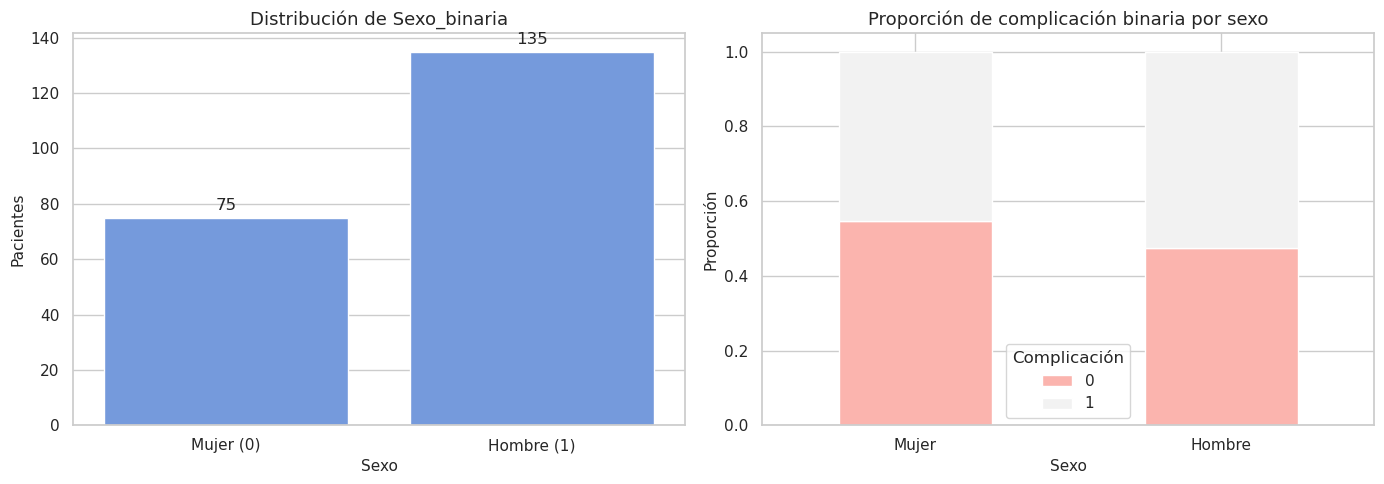

In [114]:
sex_labels = {0: 'Mujer', 1: 'Hombre'}

sex_counts = (
    df['Sexo_binaria']
    .value_counts()
    .sort_index()
    .rename_axis('Sexo_binaria')
    .reset_index(name='n_pacientes')
)
sex_counts['sexo'] = sex_counts['Sexo_binaria'].map(sex_labels)
sex_counts['porcentaje'] = (100 * sex_counts['n_pacientes'] / len(df)).round(1)
display(sex_counts[['sexo', 'n_pacientes', 'porcentaje']])

sex_comp_counts = pd.crosstab(df['Sexo_binaria'], df['Complicacion_binaria'])
sex_comp = pd.crosstab(df['Sexo_binaria'], df['Complicacion_binaria'], normalize='index')
sex_comp.index = sex_comp.index.map(sex_labels)
sex_comp_counts.index = sex_comp_counts.index.map(sex_labels)
display(sex_comp_counts)
display((sex_comp * 100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(data=df, x='Sexo_binaria', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Distribución de Sexo_binaria')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Pacientes')
axes[0].set_xticklabels(['Mujer (0)', 'Hombre (1)'])
axes[0].bar_label(axes[0].containers[0], padding=3)

sex_comp.plot(kind='bar', stacked=True, ax=axes[1], colormap='Pastel1')
axes[1].set_title('Proporción de complicación binaria por sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Complicación')
axes[1].set_xticklabels(sex_comp.index, rotation=0)

plt.tight_layout()
plt.show()

En la cohorte se observa una mayor representación de hombres que de mujeres: 135 hombres frente a 75 mujeres, lo que equivale aproximadamente al 64,3 % y 35,7 % del total, respectivamente. Esta distribución es coherente con el contexto clínico del estudio y con la información aportada por los médicos colaboradores. En generaciones previas, el consumo de tabaco fue más frecuente en hombres. Dado que el tabaquismo es uno de los principales factores de riesgo para el cáncer de pulmón, es esperable que en una cohorte de pacientes candidatos a biopsia pulmonar exista una mayor proporción de varones.

Al analizar la proporción de complicación binaria por sexo, no basta con comparar el número absoluto de complicaciones, ya que hay muchos más hombres que mujeres en el dataset. Por eso se representa la proporción dentro de cada grupo. Con la codificación empleada en el notebook (`0 = mujer`, `1 = hombre`), la tasa de complicación binaria es del 45,3 % en mujeres y del 52,6 % en hombres. Por tanto, en estos datos la complicación aparece ligeramente más frecuente en hombres que en mujeres.

## 6. Prevalencia de variables clínicas y patológicas

En esta parte analizamos qué factores aparecen con mayor frecuencia en la cohorte. Esto es útil tanto para entender el dataset como para priorizar variables en modelos posteriores.

In [115]:
feature_prev = df[feature_cols].mean().sort_values(ascending=False)
feature_prev_df = pd.DataFrame({
    'variable': feature_prev.index,
    'prevalencia': feature_prev.values,
    'n_positivos': df[feature_prev.index].sum().astype(int).values
})

display(feature_prev_df.head(25))

,variable,prevalencia,n_positivos
0,Sin_patología_pulmonar,0.633333,133
1,Tabaquismo,0.433333,91
2,HTA,0.309524,65
3,Extabaquismo,0.300000,63
4,Enfisema_centrolobulillar,0.195238,41
5,Sin_factor_de_riesgo,0.161905,34
6,Enfisema_paraseptal,0.109524,23
7,Hipertensión_pulmonar,0.080952,17
8,Dislipemia,0.066667,14
9,DM,0.047619,10


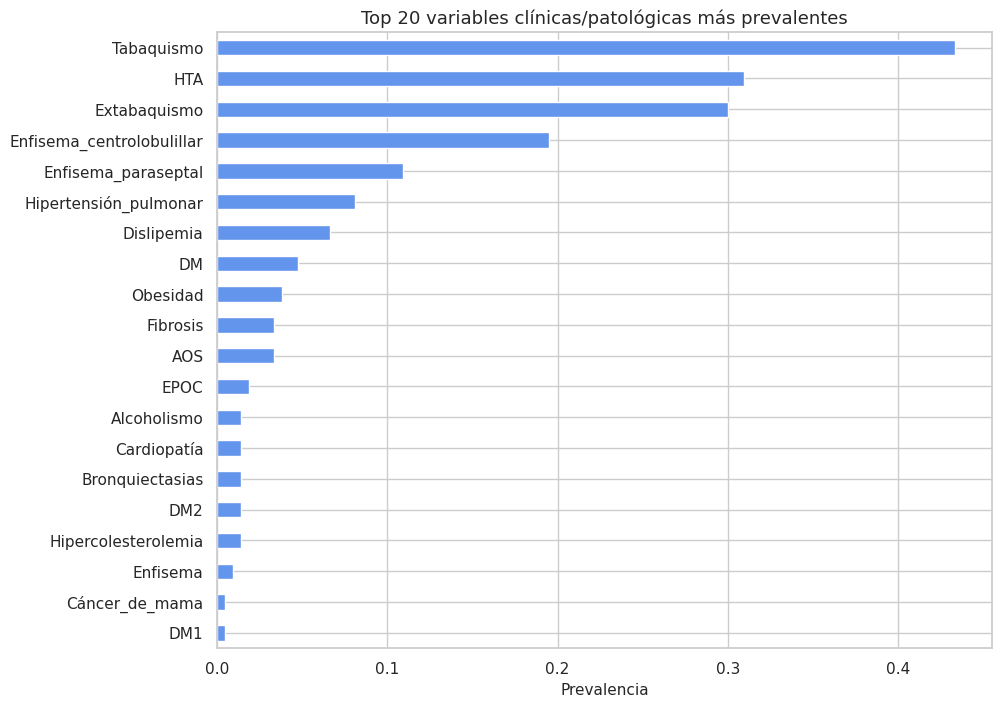

In [116]:
# quitamos sin patologia pulmonar y sin factor de riesgo para el grafico
feature_prev_clinical = feature_prev.drop(['Sin_patología_pulmonar', 'Sin_factor_de_riesgo'], errors='ignore')

plt.figure(figsize=(10,8))
feature_prev_clinical.head(20).sort_values().plot(kind='barh', color='cornflowerblue')
plt.title('Top 20 variables clínicas/patológicas más prevalentes')
plt.xlabel('Prevalencia')
plt.show()

### Frecuencia por categoría clínica original

Para distinguir los factores de riesgo de las patologías pulmonares, que en el CSV limpio aparecen mezclados como variables binarias, se representan aquí sus categorías originales. Los valores `X`, vacíos y nulos se excluyen; al ser multietiqueta, un paciente puede aparecer en más de una barra.

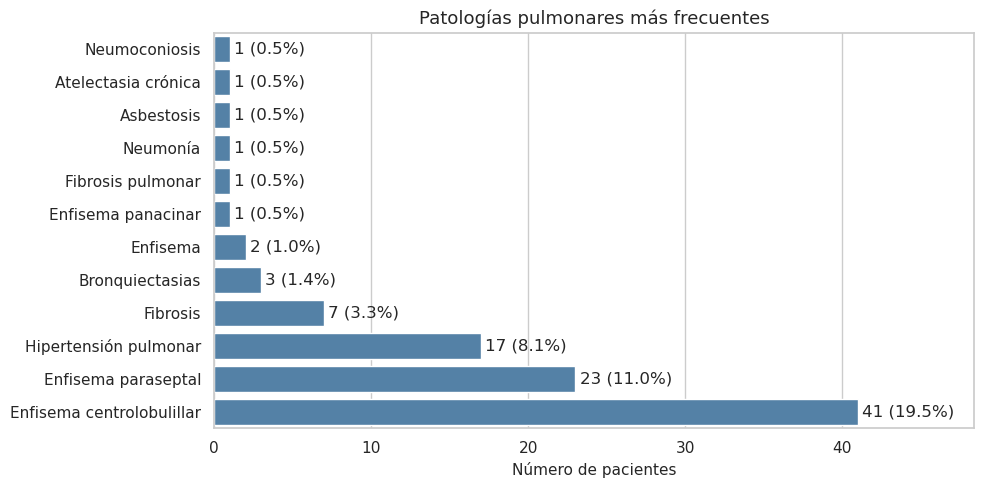

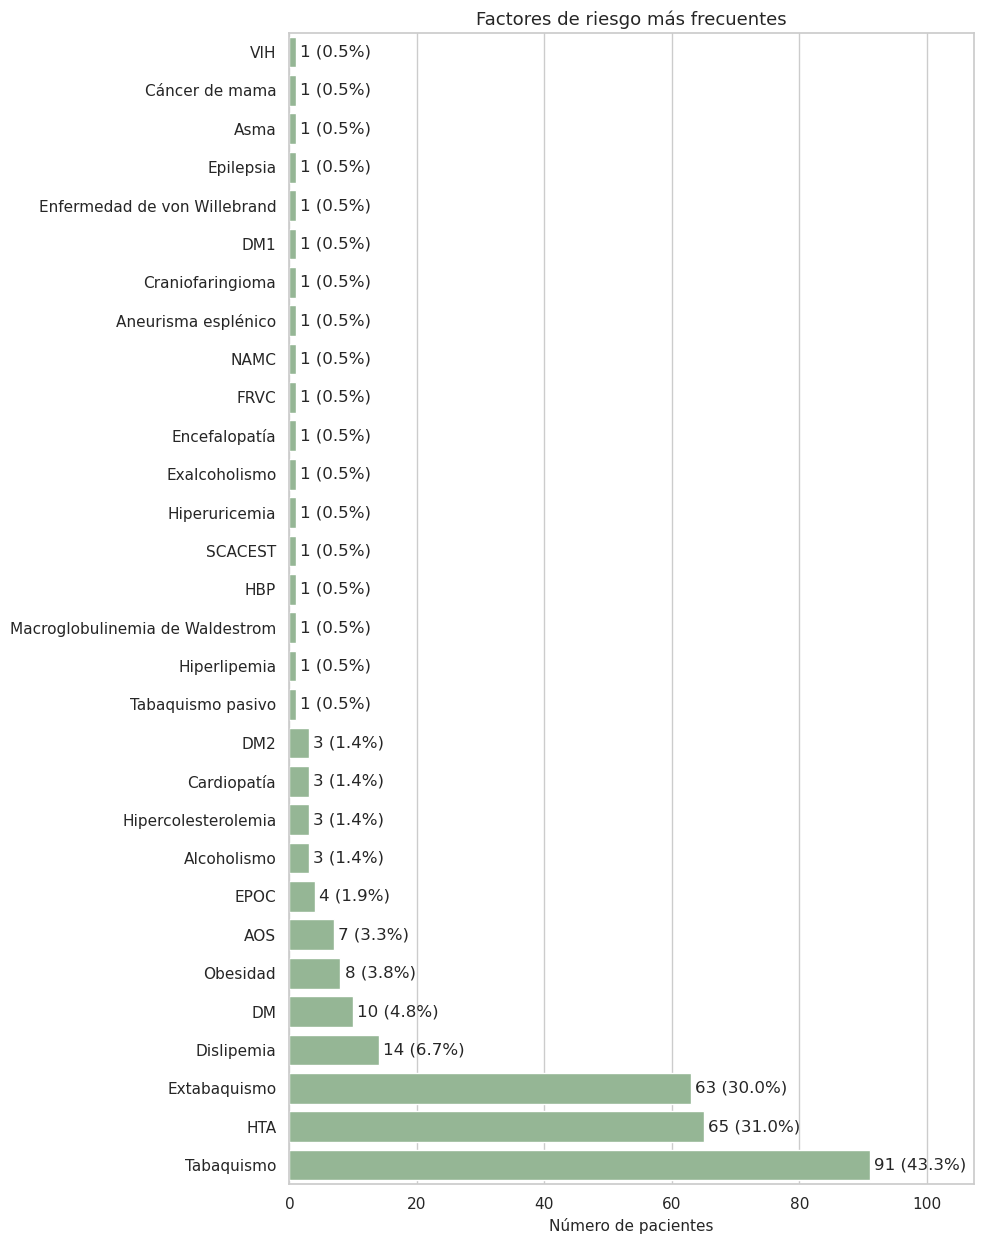

In [117]:
grafico_frecuencias(
    patologias_original, 'Patologías pulmonares más frecuentes', 'steelblue'
)
grafico_frecuencias(
    riesgos_original, 'Factores de riesgo más frecuentes', 'darkseagreen'
)

In [118]:
# Variables raras: utiles para identificar columnas con soporte muy bajo
rare_vars = feature_prev_df[feature_prev_df['n_positivos'] <= 3].sort_values(['n_positivos', 'variable'])
display(rare_vars)

,variable,prevalencia,n_positivos
24,Aneurisma_esplénico,0.004762,1
39,Asbestosis,0.004762,1
23,Asma,0.004762,1
36,Atelectasia_crónica,0.004762,1
22,Craniofaringioma,0.004762,1
21,Cáncer_de_mama,0.004762,1
20,DM1,0.004762,1
26,Encefalopatía,0.004762,1
27,Enfermedad_de_von_Willebrand,0.004762,1
41,Enfisema_panacinar,0.004762,1


## 7. Relación exploratoria entre variables y complicación

Este análisis es descriptivo. No implica causalidad ni sustituye la evaluación formal en experimentos posteriores.

### Asociación bivariante mediante test exacto de Fisher y odds ratio

Además de comparar prevalencias, se aplica el test exacto de Fisher para explorar la asociación entre cada variable clínica binaria y `Complicacion_binaria`. El odds ratio permite resumir la dirección y magnitud de la asociación, mientras que la corrección FDR ayuda a controlar el problema de comparaciones múltiples.

In [119]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

rows = []

for col in feature_cols:
    tabla = pd.crosstab(df[col], df['Complicacion_binaria'])

    if tabla.shape == (2, 2):
        odds_ratio, pvalue = fisher_exact(tabla)
        
        tasa_si = df.loc[df[col] == 1, 'Complicacion_binaria'].mean()
        tasa_no = df.loc[df[col] == 0, 'Complicacion_binaria'].mean()
        
        rows.append({
            'variable': col,
            'n_con_variable': int((df[col] == 1).sum()),
            'n_sin_variable': int((df[col] == 0).sum()),
            'tasa_complicacion_si': tasa_si,
            'tasa_complicacion_no': tasa_no,
            'diferencia_tasas': tasa_si - tasa_no,
            'odds_ratio': odds_ratio,
            'pvalue_fisher': pvalue
        })

assoc_df = pd.DataFrame(rows)

assoc_df['pvalue_fdr'] = multipletests(
    assoc_df['pvalue_fisher'],
    method='fdr_bh'
)[1]

assoc_df = assoc_df.sort_values('pvalue_fdr')

display(assoc_df.head(20))

,variable,n_con_variable,n_sin_variable,tasa_complicacion_si,tasa_complicacion_no,diferencia_tasas,odds_ratio,pvalue_fisher,pvalue_fdr
43,Sin_patología_pulmonar,133,77,0.413534,0.649351,-0.235817,0.380769,0.001549,0.068167
11,EPOC,4,206,1.000000,0.490291,0.509709,inf,0.121420,0.966321
25,Obesidad,8,202,0.125000,0.514851,-0.389851,0.134615,0.065118,0.966321
16,Extabaquismo,63,147,0.587302,0.462585,0.124717,1.653281,0.131771,0.966321
38,Fibrosis,7,203,0.857143,0.487685,0.369458,6.303030,0.118721,0.966321
40,Hipertensión_pulmonar,17,193,0.705882,0.481865,0.224017,2.580645,0.127015,0.966321
20,Hipercolesterolemia,3,207,0.000000,0.507246,-0.507246,0.000000,0.246411,0.985646
9,DM2,3,207,0.000000,0.507246,-0.507246,0.000000,0.246411,0.985646
33,Bronquiectasias,3,207,1.000000,0.492754,0.507246,inf,0.246411,0.985646
27,Sin_factor_de_riesgo,34,176,0.382353,0.522727,-0.140374,0.565217,0.189225,0.985646


En la ejecución actual no aparece ninguna variable claramente significativa tras corrección por múltiples comparaciones: `Sin_patología_pulmonar` es la señal más cercana al umbral, con una tasa de complicación menor en pacientes sin patología pulmonar registrada y un FDR de 0,068. El resto de variables tienen FDR altos, por lo que deben interpretarse como señales descriptivas. También conviene vigilar los odds ratio extremos o infinitos, porque aparecen en variables con muy pocos pacientes positivos, como EPOC o bronquiectasias, y pueden ser inestables.

### Comparación descriptiva de tasas por complicación binaria

,variable,n_con_variable,tasa_complicacion
13,EPOC,4,1.000000
12,Fibrosis,7,0.857143
7,Hipertensión_pulmonar,17,0.705882
4,Enfisema_centrolobulillar,41,0.609756
6,Enfisema_paraseptal,23,0.608696
3,Extabaquismo,63,0.587302
2,HTA,65,0.553846
8,Dislipemia,14,0.500000
1,Tabaquismo,91,0.483516
11,AOS,7,0.428571


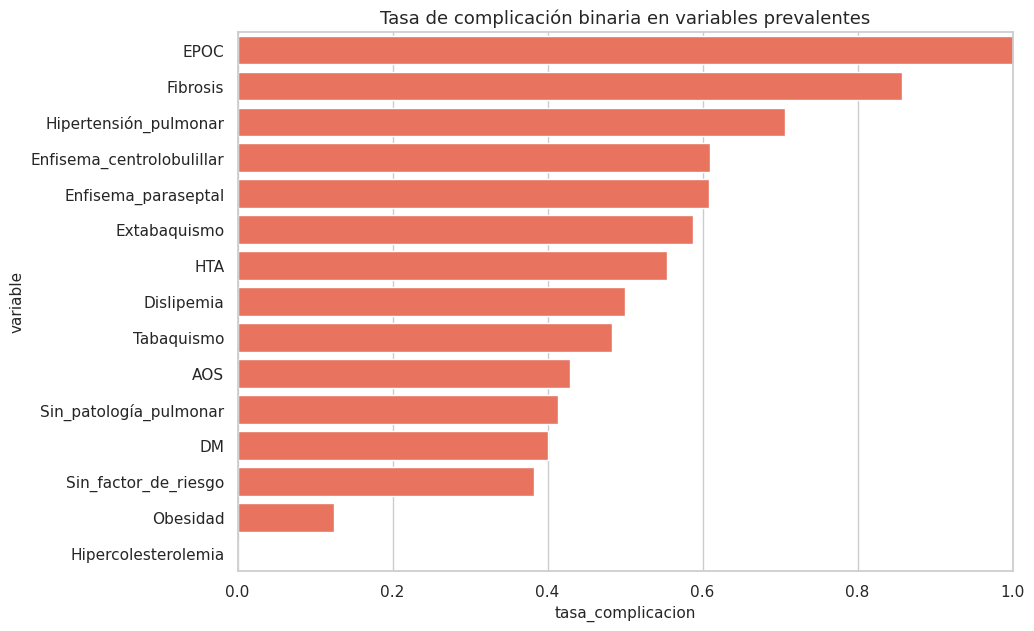

In [120]:
# Tasa de complicacion binaria en las variables mas prevalentes
selected = feature_prev.head(15).index.tolist()
rate_rows = []
for col in selected:
    positives = df.loc[df[col] == 1, 'Complicacion_binaria']
    rate_rows.append({
        'variable': col,
        'n_con_variable': int((df[col] == 1).sum()),
        'tasa_complicacion': positives.mean() if len(positives) > 0 else np.nan
    })
rate_df = pd.DataFrame(rate_rows).sort_values('tasa_complicacion', ascending=False)
display(rate_df)

plt.figure(figsize=(10,7))
sns.barplot(data=rate_df, y='variable', x='tasa_complicacion', color='tomato')
plt.title('Tasa de complicación binaria en variables prevalentes')
plt.xlim(0, 1)
plt.show()

In [121]:
# Comparacion de prevalencia por complicacion binaria
comp0 = df[df['Complicacion_binaria'] == 0][feature_cols].mean()
comp1 = df[df['Complicacion_binaria'] == 1][feature_cols].mean()
prev_compare = pd.DataFrame({
    'sin_complicacion': comp0,
    'con_complicacion': comp1,
    'diferencia': comp1 - comp0
}).sort_values('diferencia', ascending=False)

display(prev_compare.head(20))
display(prev_compare.tail(20))

,sin_complicacion,con_complicacion,diferencia
Extabaquismo,0.247619,0.352381,0.104762
Enfisema_centrolobulillar,0.152381,0.238095,0.085714
Hipertensión_pulmonar,0.047619,0.114286,0.066667
HTA,0.276190,0.342857,0.066667
Enfisema_paraseptal,0.085714,0.133333,0.047619
Fibrosis,0.009524,0.057143,0.047619
EPOC,0.000000,0.038095,0.038095
Bronquiectasias,0.000000,0.028571,0.028571
SCACEST,0.000000,0.009524,0.009524
Cardiopatía,0.009524,0.019048,0.009524


,sin_complicacion,con_complicacion,diferencia
Alcoholismo,0.019048,0.009524,-0.009524
Aneurisma_esplénico,0.009524,0.000000,-0.009524
Asma,0.009524,0.000000,-0.009524
Exalcoholismo,0.009524,0.000000,-0.009524
Neumonía,0.009524,0.000000,-0.009524
Fibrosis_pulmonar,0.009524,0.000000,-0.009524
VIH,0.009524,0.000000,-0.009524
NAMC,0.009524,0.000000,-0.009524
Hiperlipemia,0.009524,0.000000,-0.009524
Hiperuricemia,0.009524,0.000000,-0.009524


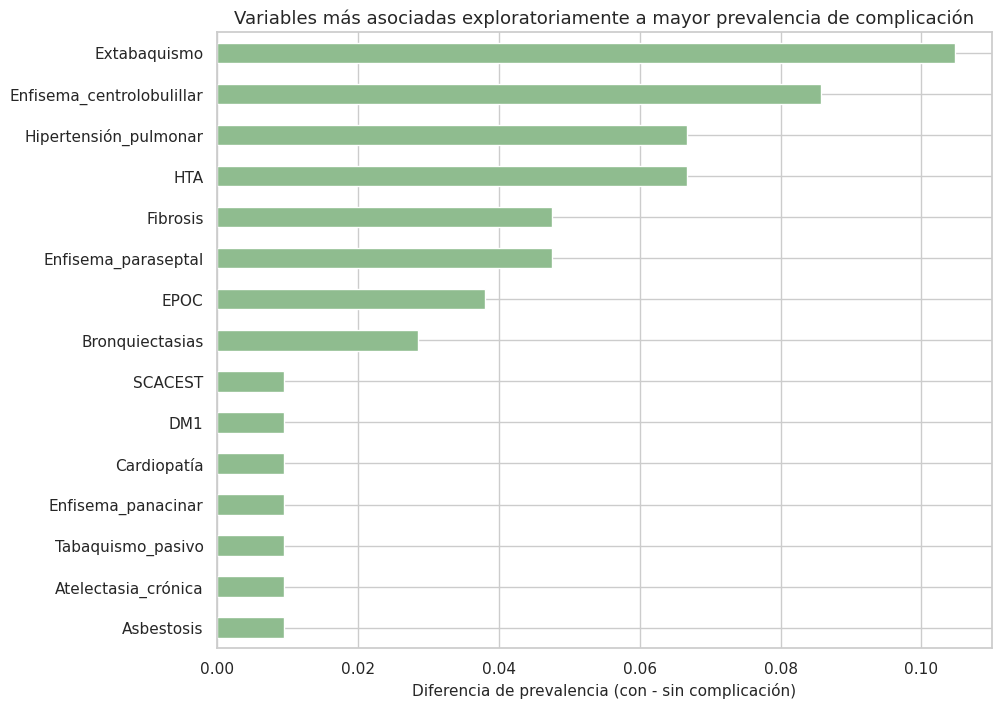

In [122]:
plt.figure(figsize=(10,8))
prev_compare['diferencia'].head(15).sort_values().plot(kind='barh', color='darkseagreen')
plt.title('Variables más asociadas exploratoriamente a mayor prevalencia de complicación')
plt.xlabel('Diferencia de prevalencia (con - sin complicación)')
plt.show()

### Perfiles clínicos de Hemorragia y Neumotórax

Analizamos si `Hemorragia` y `Neumotórax` muestran perfiles clínicos distintos comparando la prevalencia de cada variable clínica en pacientes con y sin cada etiqueta específica.

In [123]:
targets_especificos = ['Hemorragia', 'Neumotórax']

for target in targets_especificos:
    comp0 = df[df[target] == 0][feature_cols].mean()
    comp1 = df[df[target] == 1][feature_cols].mean()

    tmp = pd.DataFrame({
        'sin_etiqueta': comp0,
        'con_etiqueta': comp1,
        'diferencia': comp1 - comp0,
        'n_con_variable': df[feature_cols].sum()
    }).sort_values('diferencia', ascending=False)

    print(f'\nVariables con mayor diferencia de prevalencia para {target}')
    display(tmp.head(15))


Variables con mayor diferencia de prevalencia para Hemorragia


,sin_etiqueta,con_etiqueta,diferencia,n_con_variable
Hipertensión_pulmonar,0.049689,0.183673,0.133984,17
HTA,0.285714,0.387755,0.102041,65
Enfisema_paraseptal,0.086957,0.183673,0.096717,23
Extabaquismo,0.279503,0.367347,0.087844,63
EPOC,0.000000,0.081633,0.081633,4
Enfisema_centrolobulillar,0.180124,0.244898,0.064774,41
Tabaquismo_pasivo,0.000000,0.020408,0.020408,1
SCACEST,0.000000,0.020408,0.020408,1
Macroglobulinemia_de_Waldestrom,0.000000,0.020408,0.020408,1
Atelectasia_crónica,0.000000,0.020408,0.020408,1



Variables con mayor diferencia de prevalencia para Neumotórax


,sin_etiqueta,con_etiqueta,diferencia,n_con_variable
Fibrosis,0.006849,0.093750,0.086901,7
Enfisema_centrolobulillar,0.171233,0.250000,0.078767,41
Tabaquismo,0.417808,0.468750,0.050942,91
Bronquiectasias,0.000000,0.046875,0.046875,3
Extabaquismo,0.287671,0.328125,0.040454,63
Cardiopatía,0.006849,0.031250,0.024401,3
Asbestosis,0.000000,0.015625,0.015625,1
Neumoconiosis,0.000000,0.015625,0.015625,1
Enfisema_panacinar,0.000000,0.015625,0.015625,1
DM1,0.000000,0.015625,0.015625,1


La comparación sugiere que `Hemorragia` y `Neumotórax` no tienen exactamente el mismo perfil clínico. En los pacientes con hemorragia aparecen con mayor prevalencia variables cardiovasculares y respiratorias como hipertensión pulmonar, HTA, enfisema paraseptal, extabaquismo, EPOC y enfisema centrolobulillar. En cambio, en los pacientes con neumotórax destacan más fibrosis, enfisema centrolobulillar, tabaquismo, bronquiectasias y extabaquismo. Esta diferencia es coherente con la idea de que las complicaciones específicas podrían responder a mecanismos clínicos parcialmente distintos. 

## 8. Correlaciones exploratorias

Dado que la mayoría de variables son binarias, este mapa debe interpretarse solo como una señal inicial de asociación lineal simple.

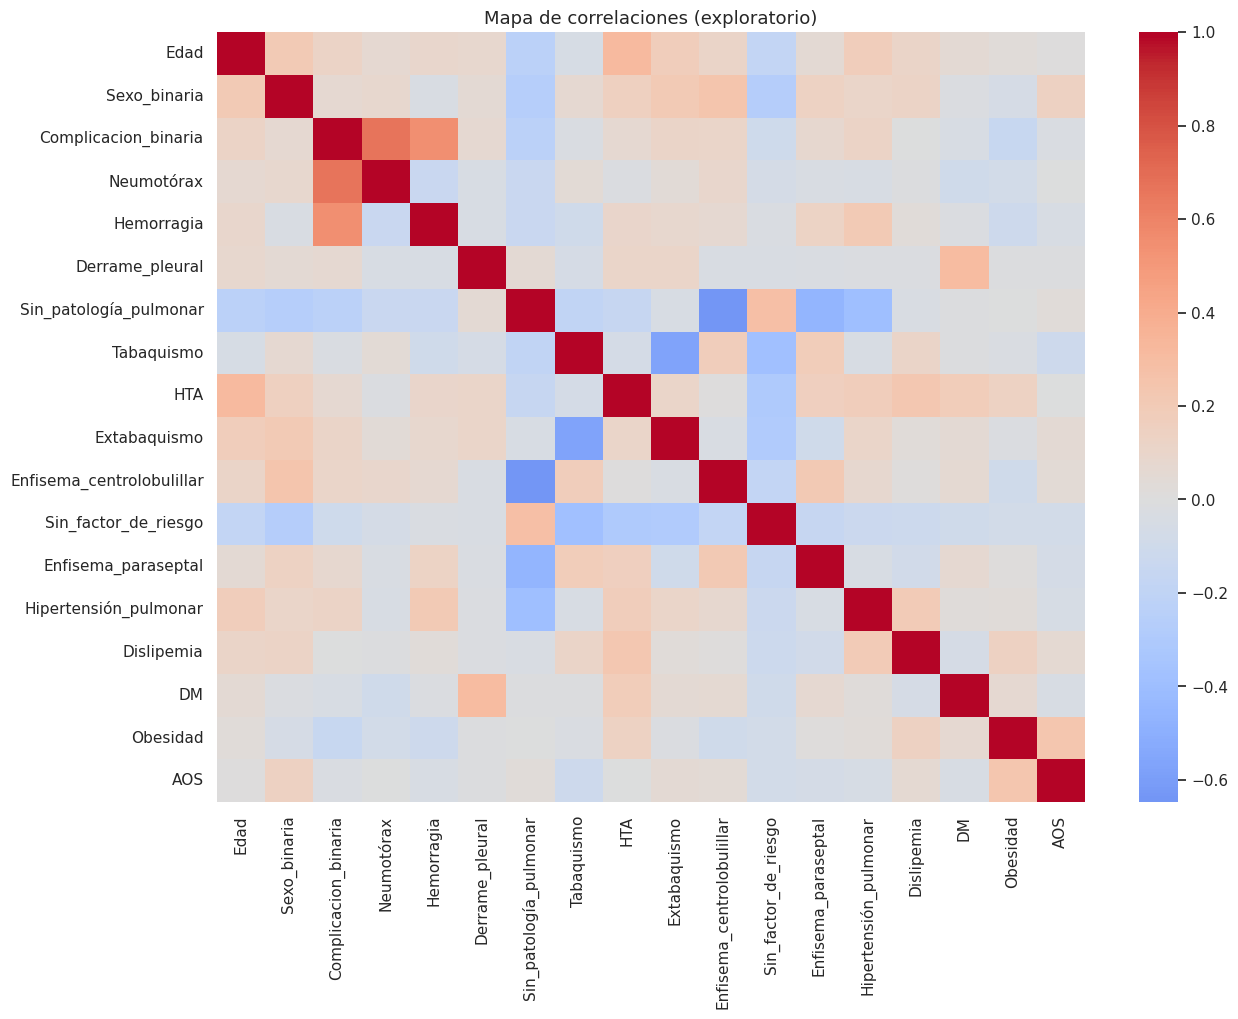

In [124]:
corr_cols = ['Edad', 'Sexo_binaria', 'Complicacion_binaria', 'Neumotórax', 'Hemorragia', 'Derrame_pleural'] + feature_prev.head(12).index.tolist()
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Mapa de correlaciones (exploratorio)')
plt.show()

In [125]:
# Correlacion especifica con las etiquetas principales
label_focus = ['Complicacion_binaria', 'Neumotórax', 'Hemorragia', 'Derrame_pleural']
label_corr = df[['Edad', 'Sexo_binaria'] + feature_cols + label_focus].corr(numeric_only=True).loc[feature_cols + ['Edad', 'Sexo_binaria'], label_focus]
display(label_corr.sort_values('Complicacion_binaria', ascending=False).head(20))

,Complicacion_binaria,Neumotórax,Hemorragia,Derrame_pleural
EPOC,1.393466e-01,-0.092259,0.252587,-0.009639
Fibrosis,1.326395e-01,0.222840,-0.102444,-0.012845
Edad,1.225129e-01,0.065646,0.089276,0.085686
Hipertensión_pulmonar,1.222067e-01,-0.044790,0.207760,-0.020529
Bronquiectasias,1.203859e-01,0.181828,-0.066414,-0.008327
Extabaquismo,1.143046e-01,0.040635,0.081076,0.105661
Enfisema_centrolobulillar,1.081203e-01,0.091469,0.069115,-0.034070
Enfisema_paraseptal,7.624042e-02,-0.033441,0.130987,-0.024259
HTA,7.210367e-02,-0.018115,0.093356,0.103313
Sexo_binaria,6.956656e-02,0.083276,-0.035245,0.051557


## 9. Conclusiones del EDA

El dataset final contiene 210 pacientes y presenta una variable objetivo binaria perfectamente equilibrada: 105 pacientes con complicación y 105 sin complicación. Además, las comprobaciones realizadas muestran que `Complicacion_binaria` es coherente con las complicaciones específicas y que `Sin_complicación` es su complementaria.

En cuanto a las complicaciones específicas (nos vamos a centrar en este proyecto en una clasificación multietiqueta), el soporte es desigual. La etiqueta más frecuente es `Neumotórax`, con 64 casos, seguida de `Hemorragia`, con 49 casos. En cambio, `Derrame_pleural` aparece únicamente en 1 paciente, por lo que no parece viable modelarla de forma independiente con esta muestra. La mayoría de pacientes con complicación tienen una sola complicación etiquetada, aunque existen 9 pacientes con dos complicaciones.

La cohorte está formada mayoritariamente por pacientes de edad avanzada. La mediana de edad es de 68 años, con un rango intercuartílico de 59 a 76 años y un rango total de 18 a 87 años. La distribución no es perfectamente normal y concentra gran parte de los casos en edades medias-altas, algo esperable en una cohorte de pacientes con sospecha o diagnóstico oncológico pulmonar. Respecto al sexo, hay más hombres que mujeres: 135 hombres frente a 75 mujeres. Esta diferencia es clínicamente plausible por el contexto histórico de mayor exposición tabáquica en varones de generaciones previas. La proporción de complicación binaria es ligeramente superior en hombres, 52,6 %, frente a 45,3 % en mujeres, aunque esta comparación es descriptiva y no permite afirmar una asociación independiente sin ajustar por otras variables.

El perfil oncológico está dominado por el adenocarcinoma, con 89 pacientes, seguido del tipo epidermoide, con 38 pacientes, y del grupo no especificado, con 35 pacientes tras agrupar las categorías equivalentes. Otras categorías como linfoma, microcítico, metástasis, neuroendocrino o cáncer de célula no pequeña tienen mucho menor soporte. Las tasas de complicación por tipo de cáncer deben interpretarse con cautela en las categorías pequeñas, ya que pocos pacientes pueden producir porcentajes aparentemente altos o bajos sin que ello implique una diferencia clínicamente sólida.

Las variables clínicas y patológicas más prevalentes son el tabaquismo, la HTA, el extabaquismo y los distintos subtipos de enfisema, especialmente el enfisema centrolobulillar. También se observa que una proporción amplia de pacientes no tiene patología pulmonar registrada. Esta última variable es útil para describir la cohorte, pero conviene interpretarla como ausencia de patología documentada y no como una patología clínica en sí misma. Las patologías pulmonares más frecuentes en el CSV original son el enfisema centrolobulillar, el enfisema paraseptal y la hipertensión pulmonar; entre los factores de riesgo destacan tabaquismo, HTA y extabaquismo.

En el análisis exploratorio de asociación con la complicación binaria no aparecen relaciones fuertes. Algunas variables como fibrosis, EPOC, hipertensión pulmonar, bronquiectasias o enfisema muestran tasas de complicación relativamente elevadas, pero varias tienen muy bajo número de casos, por lo que deben considerarse señales exploratorias y no conclusiones definitivas. Para modelos posteriores sería recomendable priorizar inicialmente variables con suficiente prevalencia y significado clínico claro, controlar las variables extremadamente raras y evitar introducir columnas redundantes o derivadas directamente de la variable objetivo.